# Pathway / Biological Interpretation

# Theme: Gene Set Enrichment Analysis (GSEA)

#### Computational oncology project combining transcriptomics, unsupervised clustering, and pathway enrichment analysis to study tumor heterogeneity in breast cancer.

#  Pathway Enrichment Analysis in TCGA-BRCA

##  Objective

To uncover the biological mechanisms underlying transcriptomic tumor subtypes in TCGA-BRCA by performing pathway enrichment analysis and linking pathway activity to clinical outcomes.

##  Background

Previous analysis identified distinct tumor clusters using gene expression data. 
This analysis aims to uncover the biological mechanisms driving these clusters by identifying enriched pathways.

In [1]:
pip install gseapy

Note: you may need to restart the kernel to use updated packages.


### Cell setup

In [2]:
import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt

## STEP 1 — Create a clean working file

In [7]:
expr = pd.read_csv("TCGA.BRCA.sampleMap_HiSeqV2.gz", sep="\t", index_col=0)
mutation = pd.read_csv("mc3.v0.2.8.PUBLIC.xena", sep="\t", comment='#')
clinical = pd.read_csv("TCGA-BRCA.clinical.tsv", sep="\t")

## STEP 2 — Recreate cleaned expression (IMPORTANT)

In [9]:
# transpose → patient × gene
expr = expr.T

# standardize IDs
expr.index = expr.index.str[:12]

# remove duplicates
expr = expr[~expr.index.duplicated()]

## STEP 3 — Add clustering again (reuse logic)

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# select top genes
gene_variance = expr.var(axis=0)
top_genes = gene_variance.sort_values(ascending=False).head(2000).index

expr_subset = expr[top_genes]

# scale
scaler = StandardScaler()
expr_scaled = scaler.fit_transform(expr_subset)

# clustering
kmeans = KMeans(n_clusters=4, random_state=42)
expr['cluster'] = kmeans.fit_predict(expr_scaled)

## STEP 4 — SAVE THIS (MOST IMPORTANT STEP )

In [13]:
import os
os.makedirs("processed_data", exist_ok=True)

In [14]:
# Save cleaned dataset:

In [15]:
expr.to_csv("processed_data/expr_with_clusters.csv")

In [ ]:
# From now on, use the saved dataset

In [16]:
expr = pd.read_csv("processed_data/expr_with_clusters.csv", index_col=0)

##  Method

We compare each cluster against all other samples to identify genes that are differentially expressed. 
These ranked genes are then used for pathway enrichment analysis (GSEA).

## STEP 5 — Now continue this Project as clean data is ready

## Cluster 3 (Worst survival)

In [17]:
cluster_id = 3

group1 = expr[expr['cluster'] == cluster_id]
group2 = expr[expr['cluster'] != cluster_id]

group1 = group1.drop(columns=['cluster'])
group2 = group2.drop(columns=['cluster'])

diff = group1.mean() - group2.mean()

ranked_genes = diff.sort_values(ascending=False)

## STEP 6 — Prepare for GSEA

In [18]:
ranked_genes = ranked_genes.reset_index()
ranked_genes.columns = ['gene', 'score']

## STEP 7 — Run GSEA

In [19]:
import gseapy as gp

gsea_results = gp.prerank(
    rnk=ranked_genes,
    gene_sets='KEGG_2016',
    outdir=None,
    seed=42
)

2026-04-06 15:21:07,954 [WARNING] Duplicated values found in preranked stats: 1.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


## STEP 8 — View results

In [21]:
gsea_results.res2d.head(10)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Cell cycle Homo sapiens hsa04110,0.606031,2.20274,0.0,0.0,0.0,44/118,9.61%,SMC1B;CCNE1;CDC20;CDKN2A;TTK;PLK1;CDC45;CDC25A...
1,prerank,Glycosphingolipid biosynthesis - lacto and neo...,0.765675,2.153625,0.0,0.0,0.0,14/26,11.89%,B3GNT5;FUT3;B3GNT3;ST8SIA1;B3GNT4;GCNT2;ST3GAL...
2,prerank,Graft-versus-host disease Homo sapiens hsa05332,0.691975,2.027133,0.0,0.0,0.0,27/37,24.62%,HLA-DOB;GZMB;TNF;IFNG;HLA-F;IL1A;PRF1;IL6;CD80...
3,prerank,Ribosome biogenesis in eukaryotes Homo sapiens...,0.581902,1.982796,0.0,0.000825,0.003,46/74,27.02%,RPP25;POP1;GTPBP4;RIOK1;RPP40;DKC1;FBL;CIRH1A;...
4,prerank,Allograft rejection Homo sapiens hsa05330,0.675618,1.981769,0.0,0.00066,0.003,25/35,28.03%,HLA-DOB;GZMB;IL12A;TNF;IFNG;HLA-F;PRF1;CD80;HL...
5,prerank,Natural killer cell mediated cytotoxicity Homo...,0.51569,1.881834,0.0,0.004398,0.023,64/127,26.94%,SHC4;RAET1L;ULBP1;ULBP3;ULBP2;GZMB;TNF;IFNG;PL...
6,prerank,Tyrosine metabolism Homo sapiens hsa00350,-0.651805,-1.879974,0.0,0.020174,0.021,12/35,6.23%,TAT;HGD;ADH1B;PNMT;ALDH3B2;MAOA;ADH1C;TPO;FAH;...
7,prerank,Primary immunodeficiency Homo sapiens hsa05340,0.641871,1.869759,0.0,0.005183,0.031,29/36,29.99%,TNFRSF13C;TAP2;CD19;ICOS;CD79A;TAP1;LCK;CD8B;J...
8,prerank,Regulation of lipolysis in adipocytes Homo sap...,-0.610361,-1.868585,0.0,0.013755,0.029,18/56,9.78%,ADCY5;PLIN1;PTGER3;ADCY1;NPY1R;CGA;FABP4;AQP7;...
9,prerank,DNA replication Homo sapiens hsa03030,0.637542,1.857959,0.0,0.005223,0.034,20/36,17.15%,MCM2;RFC4;MCM7;MCM4;MCM5;MCM6;DNA2;FEN1;PRIM2;...


##  Results – Cluster 3 (Poor Survival Subtype)

Cluster 3 demonstrates strong enrichment of pathways related to:

- Cell cycle and DNA replication → indicating high proliferative activity  
- Ribosome biogenesis → increased protein synthesis capacity  
- Immune-related pathways → suggesting tumor-immune interactions  

Together, these results indicate that Cluster 3 represents a highly active tumor phenotype characterized by rapid growth and complex biological interactions, consistent with its poor survival outcome.

In [23]:
# GSEA plot (very high impact)

<Axes: title={'center': 'Top Enriched Pathways - Cluster 3'}, xlabel='$- \\log_{10}$ (FDR q-val)'>

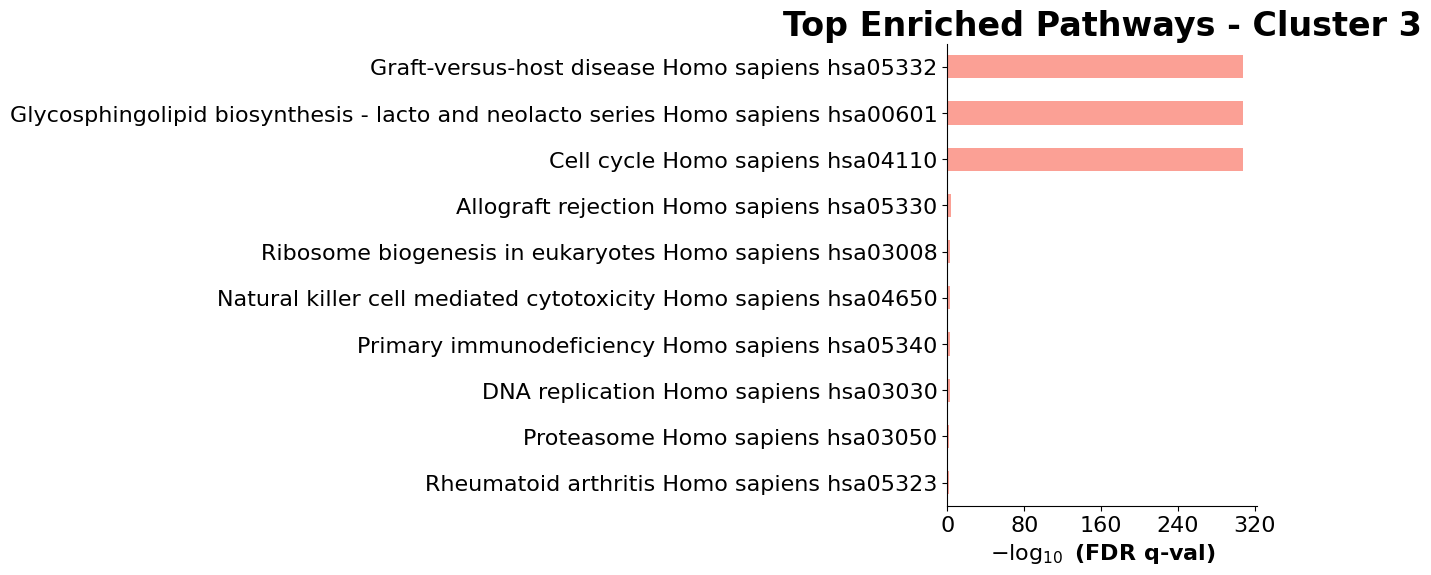

In [26]:
gp.plot.barplot(gsea_results.res2d,column='FDR q-val', title="Top Enriched Pathways - Cluster 3")

In [28]:
gp.plot.barplot(
    gsea_results.res2d,
    column='FDR q-val',
    title="Top Enriched Pathways - Cluster 3",
    ofname="figures/gsea_cluster3.png"
)

## Cluster 2 (TP53-rich)

## Run GSEA again

In [30]:

cluster_id = 2

group1 = expr[expr['cluster'] == cluster_id]
group2 = expr[expr['cluster'] != cluster_id]

group1 = group1.drop(columns=['cluster'])
group2 = group2.drop(columns=['cluster'])

diff = group1.mean() - group2.mean()

ranked_genes = diff.sort_values(ascending=False)


## Prepare for GSEA

In [31]:

ranked_genes = ranked_genes.reset_index()
ranked_genes.columns = ['gene', 'score']

## Run GSEA

In [32]:
import gseapy as gp

gsea_results = gp.prerank(
    rnk=ranked_genes,
    gene_sets='KEGG_2016',
    outdir=None,
    seed=42
)

2026-04-06 18:12:05,248 [WARNING] Duplicated values found in preranked stats: 1.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


## View results

In [33]:
gsea_results.res2d.head(10)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,DNA replication Homo sapiens hsa03030,-0.769602,-2.488929,0.0,0.0,0.0,25/36,16.33%,POLE2;MCM2;RNASEH2A;DNA2;MCM4;FEN1;PCNA;RFC4;L...
1,prerank,Cell cycle Homo sapiens hsa04110,-0.621186,-2.471485,0.0,0.0,0.0,43/118,10.46%,PKMYT1;CDC25C;BUB1;CDC45;CDC20;PLK1;CCNB2;BUB1...
2,prerank,Proteasome Homo sapiens hsa03050,-0.680686,-2.384037,0.0,0.0,0.0,38/44,27.03%,PSME2;PSMC4;PSMB3;PSMD3;PSMD14;PSMA5;PSMB4;PSM...
3,prerank,Systemic lupus erythematosus Homo sapiens hsa0...,-0.58147,-2.291051,0.0,0.0,0.0,57/125,12.58%,HIST1H3H;HIST1H3D;HIST1H2AM;HIST1H4H;HIST2H2AA...
4,prerank,Fanconi anemia pathway Homo sapiens hsa03460,-0.654027,-2.24901,0.0,0.0,0.0,19/46,11.50%,UBE2T;RAD51;EME1;FANCA;BRIP1;BLM;FANCI;FANCD2;...
5,prerank,Homologous recombination Homo sapiens hsa03440,-0.711318,-2.167744,0.0,0.0,0.0,11/27,10.90%,RAD54L;RAD51;EME1;BLM;RAD54B;XRCC2;BRCA2;POLD1...
6,prerank,Spliceosome Homo sapiens hsa03040,-0.516066,-2.105464,0.0,0.000689,0.003,61/116,30.19%,LSM4;SNRPB;SNRPA1;SNRPE;SNRPG;SF3B4;SNRPD1;LSM...
7,prerank,Mismatch repair Homo sapiens hsa03430,-0.710128,-2.073185,0.004065,0.000804,0.004,14/23,19.15%,EXO1;PCNA;RFC4;LIG1;RFC2;POLD1;RPA3;POLD4;RFC3...
8,prerank,Drug metabolism - cytochrome P450 Homo sapiens...,0.702032,2.019269,0.0,0.0,0.0,33/66,18.64%,ADH1B;ADH1A;ADH1C;FMO2;GSTM5;MAOA;GSTA1;ALDH3A...
9,prerank,Base excision repair Homo sapiens hsa03410,-0.622397,-1.978578,0.0,0.00143,0.008,19/33,20.75%,NEIL3;POLE2;FEN1;PCNA;PARP1;LIG1;NTHL1;POLD1;L...


##  Results – Cluster 2 (TP53-Enriched Subtype)

Cluster 2 shows enrichment of pathways associated with DNA damage response and genomic instability.

This is consistent with the high prevalence of TP53 mutations observed in this cluster, suggesting that tumor behavior in this subtype is driven by impaired genome maintenance mechanisms rather than increased proliferation.

In [ ]:
# GSEA plot (very high impact)

<Axes: title={'center': 'Top Enriched Pathways - Cluster 2'}, xlabel='$- \\log_{10}$ (FDR q-val)'>

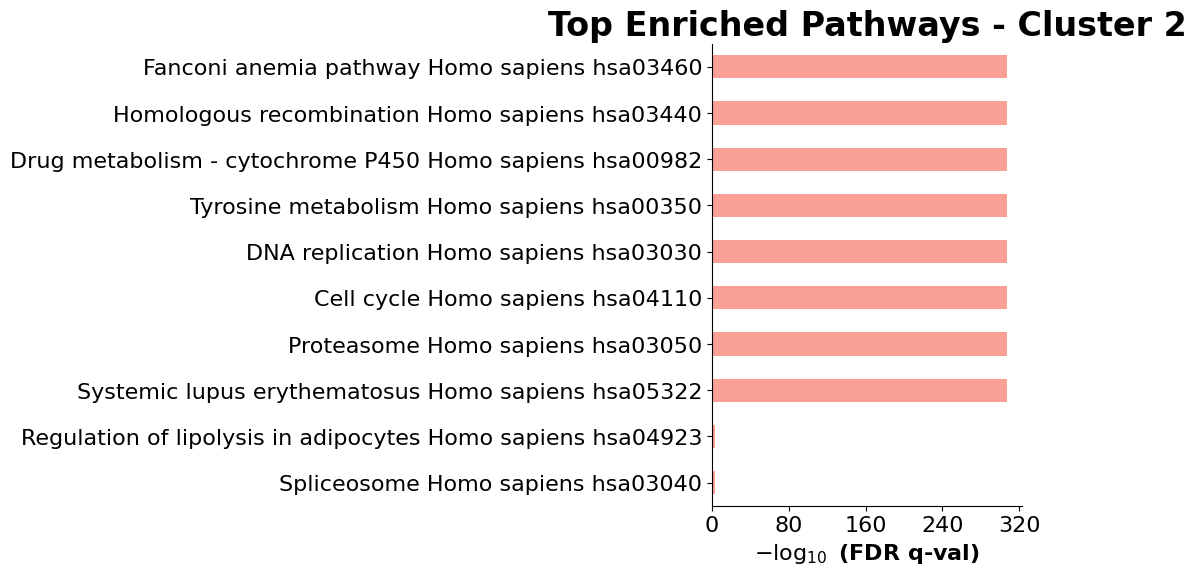

In [34]:
gp.plot.barplot(gsea_results.res2d,column='FDR q-val', title="Top Enriched Pathways - Cluster 2")

In [35]:
gp.plot.barplot(
    gsea_results.res2d,
    column='FDR q-val',
    title="Top Enriched Pathways - Cluster 2",
    ofname="figures/gsea_cluster2.png"
)

## COMPARISON

##  Comparative Insight

The analysis reveals distinct biological programs across tumor subtypes:

- Cluster 3 is driven by proliferative and translational activity, explaining its association with poor survival  
- Cluster 2 is driven by genomic instability and DNA damage pathways, reflecting TP53-associated tumor biology  

These findings demonstrate that tumor aggressiveness arises from diverse and subtype-specific biological mechanisms rather than a single unifying pathway.

## CONCLUSION 

This study demonstrates that pathway-level analysis provides critical insight into tumor heterogeneity beyond individual gene mutations.

Distinct tumor subtypes are characterized by different biological drivers, including proliferation and genomic instability, which contribute to their clinical behavior.

These findings highlight the importance of integrating transcriptomic and pathway analysis to understand cancer biology.